# VLM Comparison Experiment: Detecting Changes Between Reference and New Photo

**Goal:** Generate a list of differences by comparing a new photo of a storage unit (pantry, fridge, minibar) to its reference photo.

## What is a VLM?

A VLM (Vision-Language Model) is an AI model that understands both images and text. We give it one or more photos and a plain-language question, for example, "What is different between these two photos?", and it answers in text. It doesn't need to be trained for our shelves, it can describe what it sees out of the box.

## Why use VLMs here?

The current pipeline compares image embeddings, which only say how similar two photos look. They do not say what changed. A VLM can tell us which item was removed, added, or replaced, and name it, which is what a shopping list needs.

## What this experiment covers

Comparing a few online VLMs on the same task: given a reference photo and a new photo of the same storage unit, detect what changed.

Each model gets the same data and the same prompt, and its answer is checked against the ground truth captured on the device.

**Data source:** the `data/` folder next to this notebook (storages `Hotel minibar`, `pantry` and `vitrina`, with their golden comparison photos), and a sealed copy taken from the device.

## Why Not Run the VLM on the Phone?

Before comparing online models, we tried a local (on-device) model. Google's AI Edge Gallery app was used to run Gemma 3n E4B on a phone, with two Hotel minibar photos and the prompt "what do you see on these images, what are the differences between them".

<table width="100%">
<tr>
<td align="center" width="33%"><img src="local_vlm_testing_screenshots/Screenshot_20260919_212652.jpg" width="100%"><br><sub>Model sizes offered for download</sub></td>
<td align="center" width="33%"><img src="local_vlm_testing_screenshots/Screenshot_20260919_212706.jpg" width="100%"><br><sub>Memory warning when starting a model</sub></td>
<td align="center" width="33%"><img src="local_vlm_testing_screenshots/Screenshot_20260919_213148.jpg" width="100%"><br><sub>Prompt and start of the answer</sub></td>
</tr>
<tr>
<td align="center" width="33%"><img src="local_vlm_testing_screenshots/Screenshot_20260919_213206.jpg" width="100%"><br><sub>Answer, description of both photos</sub></td>
<td align="center" width="33%"><img src="local_vlm_testing_screenshots/Screenshot_20260919_213222.jpg" width="100%"><br><sub>Summary of differences (ran on CPU, 1.6 min)</sub></td>
<td width="33%"></td>
</tr>
</table>

**What we saw:**
- The model was mostly successful at detecting the change: it noticed that the number of Coca-Cola cans went down (4 to 3). It also invented a change in the type of drink (Zero Sugar to Regular).
- The models are 3.7 GB to 4.9 GB, and the app warned that the model may exceed the device memory.
- One answer took 1.6 minutes on the phone CPU.

**Why it is ruled out:** the quality is acceptable, but the size, the download request and the latency are not. Even if the model is not stored inside the app, but in shared device storage, the user would have to download several GB before the first scan, and every scan would take minutes. We cannot ship this, so the experiment continues with online VLMs.


## Why Only Google Models?

We test only the Gemini family. Models from other providers (for example OpenAI or Anthropic) are not part of this experiment. The reason is not that Gemini is the most accurate model, but that it fits this project best.

- **Safe use from the app:** a key for a model provider is a secret that pays for requests, and a key stored in an Android app can be extracted from the APK. With Firebase AI Logic the app holds no secret model key: it only holds the Firebase project config, and the real Gemini key stays on Google's side. The app already uses Firebase for login.
- **App Check (planned):** The Firebase project config can be copied from the app, so we also need to make sure only our genuine app can send requests. Firebase App Check does this. The app gets a short-lived token from Play Integrity, which checks that the app is signed with our key, installed from Google Play, and running on a genuine device. Firebase AI Logic rejects requests without a valid token. App Check is not set up in the app yet. It needs the App Check library, registering the app in the Firebase console, and turning on enforcement, which Firebase requires from 2 November 2026. Debug builds need a separate debug provider. App Check checks the app, not the user, so quota and budget limits should also be set in Google Cloud.
- **No extra backend:** using another provider safely would require our own server between the app and the model, which we would have to build, host, and pay for. This is out of scope for this project.
- **Price:** Gemini has small and cheap models (Flash-Lite, Flash), which suits a shopping list app that sends a request on every scan.
- **Fair comparison:** testing different sizes of one family (same API, same input format, same limits) shows the trade-off between quality, latency, and cost without other differences getting in the way.
- **Accuracy is good enough to try:** on the [Arena vision leaderboard](https://arena.ai/leaderboard/vision) (human votes, snapshot 13 September 2026), Gemini models are not first. The best Gemini model (gemini-3-pro, rank 12) is about 20 points behind the top model, and the Gemini Flash models are close to it. The leaderboard measures general image chat preferences, not change detection on shelves, so it is only a rough guide.

Comparing with models from other providers is left for future work.

## Which Gemini Models We Test

Gemini comes in three tiers: Flash-Lite (cheapest and fastest), Flash (balanced), and Pro (most capable, slowest, and most expensive). We test one model from each tier, plus the Flash model already used in the grid experiment and the model the app uses now. All of them are available through Firebase AI Logic and accept images.

| Tier | Model | Status | Input / output price (per 1M tokens) | Why |
|---|---|---|---|---|
| Flash-Lite | `gemini-3.5-flash-lite` | Stable | $0.30 / $2.50 | Cheapest option. Shows if a small model is good enough. |
| Flash | `gemini-3.5-flash` | Stable | $1.50 / $9.00 | Used in the grid experiment (`01_vlm_roi`). Baseline. |
| Flash | `gemini-3.6-flash` | Stable | $0.75 / $3.75 (promotional until 31 Dec 2026, then $1.50 / $7.50) | The model the app uses now (`LlmConstants.kt`). Baseline for the comparison. |
| Flash | `gemini-3.8-flash` | Stable | $0.75 / $3.75 (promotional until 31 Dec 2026, then $1.50 / $7.50) | Newest Flash. Shows if a newer model is better than 3.5. |
| Pro | `gemini-3.1-pro-preview` | Preview | $2.00 / $12.00 | Upper limit of quality. Shows what more money buys. |

Prices are per 1M tokens, and thinking tokens are billed as output. Our requests are far below 200k prompt tokens, so only the lower Pro price applies. The prices, model status, and Firebase support were checked on 20 September 2026 (the pricing page shows 16 September 2026 as its last update):
- [Gemini API pricing](https://ai.google.dev/gemini-api/docs/pricing)
- [Gemini API models](https://ai.google.dev/gemini-api/docs/models)
- [Firebase AI Logic supported models](https://firebase.google.com/docs/ai-logic/models)

**Notes:**
- The Pro model is still in preview and is not meant for production. It is used here only to see how far quality can go.
- We compare quality, latency, and cost per scan, using the same prompt and the same photos for every model.
- Older models (Gemini 2.5) are not tested.


## The Data

The data was captured on a phone with the capture variant of the app. Each storage unit (pantry, minibar, display cabinet) has one **reference photo**, taken once. Later, a **new photo** of the same unit is taken, and the change between the two is entered by hand as the **ground truth**. One reference with one new photo and its ground truth is called a *golden comparison*.

All files are in `data/`, next to this notebook:
- `storages/<id>/`: the storage name (`meta.json`), the reference photo (`latest/photo.jpg`), and the cell names, shelf grid and marked items (`latest/data.json`).
- `golden/comparisons/<name>/`: the new photo (`photo.jpg`), and `meta.json` with the capture details, the reference photo used and the ground truth. An older reference photo, when one was used, is saved next to it as `reference.jpg`.

Only Hotel minibar, pantry and vitrina are used. They have 2, 3 and 1 cells, and 10 golden comparisons in total.

In [14]:
import json
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from PIL import Image

nb_file = globals().get("__vsc_ipynb_file__")
NOTEBOOK_DIR = Path(nb_file).parent if nb_file else Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
STORAGES_DIR = DATA_DIR / "storages"
GOLDENS_DIR = DATA_DIR / "golden" / "comparisons"

print(f"data: {DATA_DIR.relative_to(NOTEBOOK_DIR.parent).as_posix()}")

data: vlm_comparison_experiment/data


### Loading

The ground truth lists only the changes. Each entry has the `cell`, the `change` (`ADDED`, `REMOVED` or `REPLACED`) and, when the changed item is one of the marked items, its `item_id`. An added item may also have a `box`. A golden comparison with an empty list has no changes.

In [15]:
def load_storages(storages_dir):
    storages = {}
    for storage_dir in sorted(storages_dir.iterdir()):
        meta = json.loads((storage_dir / "meta.json").read_text(encoding="utf-8"))
        data = json.loads((storage_dir / "latest" / "data.json").read_text(encoding="utf-8"))
        storages[meta["id"]] = {
            "name": meta["name"],
            "cell_names": data["cells"],
            "marked_items": data["markedItems"],
            "row_lines": sorted(g["position"] for g in data["guideLines"] if g["isHorizontal"]),
            "column_lines": sorted(g["position"] for g in data["guideLines"] if not g["isHorizontal"]),
        }
    return storages


def load_goldens(goldens_dir, storages):
    goldens = {}
    for golden_dir in sorted(goldens_dir.iterdir()):
        meta = json.loads((golden_dir / "meta.json").read_text(encoding="utf-8"))
        storage = storages[meta["storage_id"]]
        reference_path = DATA_DIR / meta["reference"]
        goldens[golden_dir.name] = {
            "storage_name": storage["name"],
            "marked_items": storage["marked_items"],
            "row_lines": storage["row_lines"],
            "column_lines": storage["column_lines"],
            "photo_path": golden_dir / "photo.jpg",
            "reference_photo_path": reference_path,
            "reference_version": "latest" if reference_path.parent.name == "latest" else "older photo",
            "ground_truth": meta["ground_truth"],
        }
    return goldens


def describe_changes(golden):
    changes_by_cell = {}
    for entry in golden["ground_truth"]:
        changes = changes_by_cell.setdefault(entry["cell"], [])
        if entry["change"] not in changes:
            changes.append(entry["change"])
    return "; ".join(
        f"{cell}: {', '.join(changes)}" for cell, changes in changes_by_cell.items()
    ) or "no change"


def has_item_markings(golden):
    return bool(golden["ground_truth"]) and all("item_id" in entry or "box" in entry for entry in golden["ground_truth"])


storages = load_storages(STORAGES_DIR)
goldens = load_goldens(GOLDENS_DIR, storages)

print(f"storages: {[s['name'] for s in storages.values()]}")
print(f"golden comparisons: {len(goldens)}")

storages: ['Hotel minibar', 'pantry', 'vitrina']
golden comparisons: 10


### Comparisons Without Item Markings

For these comparisons, the ground truth only says which cell changed, or that nothing changed. Each box holds one comparison: the reference photo on the left, the new photo on the right with the storage grid and cell names drawn over it, and the changes below. Two comparisons are shown per row.

The new photos are raw. They are not aligned to the reference (no homography is applied), so the shelves can be slightly shifted or at a different angle. In the app, the new photo is aligned before it is compared. Because of the same shift, the grid drawn over the new photos is approximate.


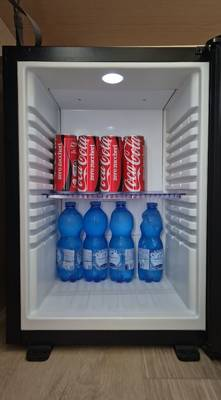
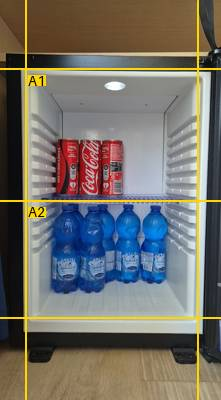
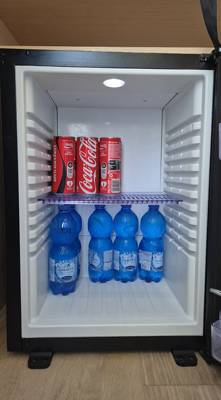
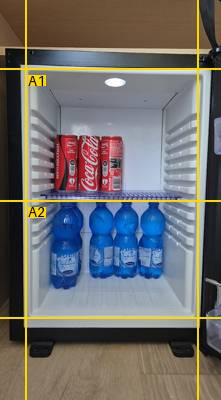
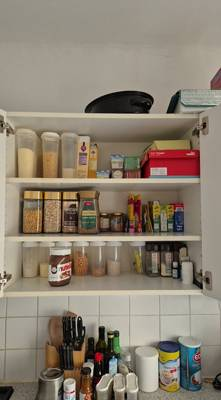
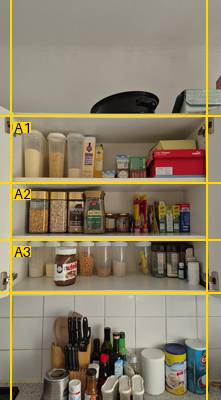
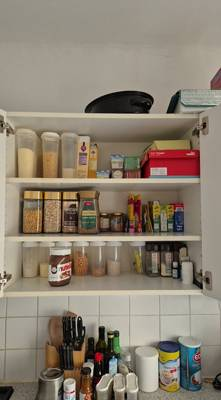
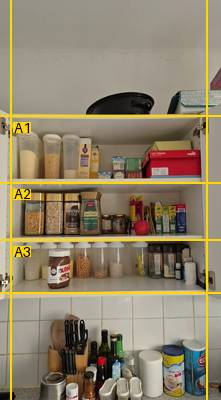
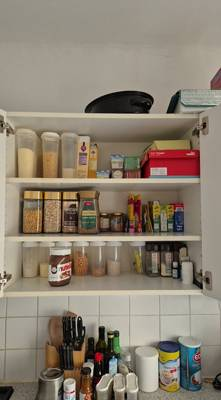
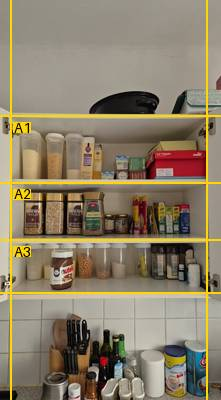

In [16]:
import base64
import html
from io import BytesIO

from PIL import ImageDraw, ImageFont

THUMBNAIL_WIDTH = 200
PAIRS_PER_ROW = 2
GRID_COLOR = (255, 215, 0)
LABEL_TEXT_COLOR = (0, 0, 0)
LABEL_FONT_SIZE = 14


def load_label_font():
    try:
        return ImageFont.load_default(size=LABEL_FONT_SIZE)
    except TypeError:
        return ImageFont.load_default()


def draw_grid(image, golden):
    draw = ImageDraw.Draw(image)
    font = load_label_font()
    width, height = image.size
    row_edges = [line * height for line in golden["row_lines"]]
    column_edges = [line * width for line in golden["column_lines"]]
    for y in row_edges:
        draw.line([(0, y), (width, y)], fill=GRID_COLOR, width=2)
    for x in column_edges:
        draw.line([(x, 0), (x, height)], fill=GRID_COLOR, width=2)
    for row_index, (top, _) in enumerate(zip(row_edges, row_edges[1:])):
        for column_index, (left, _) in enumerate(zip(column_edges, column_edges[1:])):
            label = f"{chr(ord('A') + column_index)}{row_index + 1}"
            text_box = draw.textbbox((left + 3, top + 3), label, font=font)
            draw.rectangle(text_box, fill=GRID_COLOR)
            draw.text((left + 3, top + 3), label, fill=LABEL_TEXT_COLOR, font=font)


def photo_as_data_uri(path, golden=None):
    image = Image.open(path).convert("RGB")
    image.thumbnail((THUMBNAIL_WIDTH * 2, THUMBNAIL_WIDTH * 2))
    if golden is not None:
        draw_grid(image, golden)
    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=70)
    return "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")


def caption(golden):
    older_reference = " (older reference)" if golden["reference_version"] != "latest" else ""
    return describe_changes(golden) + older_reference


def pair_html(golden):
    image_style = f"width:{THUMBNAIL_WIDTH}px; vertical-align:top;"
    return (
        '<td style="border:1px solid #888; padding:4px; text-align:center; vertical-align:top;">'
        f'<img src="{photo_as_data_uri(golden["reference_photo_path"])}" style="{image_style}">'
        f'<img src="{photo_as_data_uri(golden["photo_path"], golden)}" style="{image_style} margin-left:4px;">'
        f'<br><sub>{html.escape(caption(golden))}</sub>'
        "</td>"
    )


golden_list = [golden for golden in goldens.values() if not has_item_markings(golden)]
rows = []
for start in range(0, len(golden_list), PAIRS_PER_ROW):
    row_goldens = golden_list[start:start + PAIRS_PER_ROW]
    rows.append("<tr>" + "".join(pair_html(golden) for golden in row_goldens) + "</tr>")

display(HTML(
    '<table style="border-collapse:separate; border-spacing:8px;">' + "".join(rows) + "</table>"
))

### Comparisons With Item Markings

For these comparisons, the ground truth points to the marked items that changed. The left photo is the reference with every marked item outlined and named. The right photo is the new photo with the changed items filled in: red for `REMOVED`, green for `ADDED`.

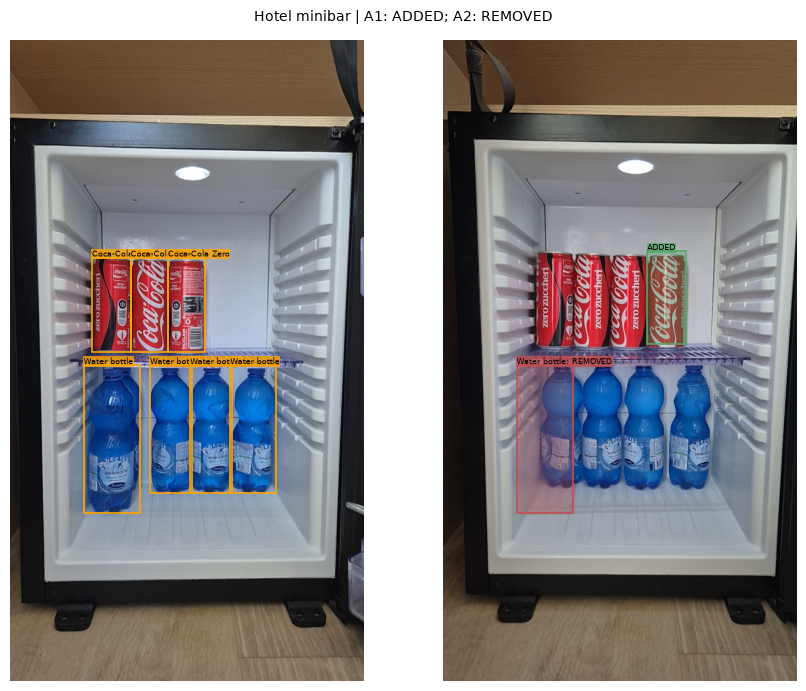

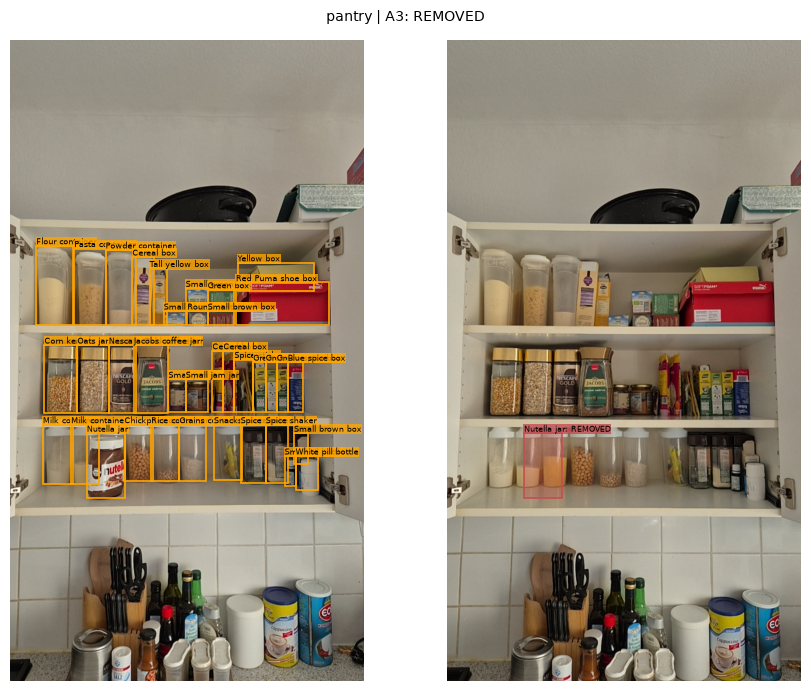

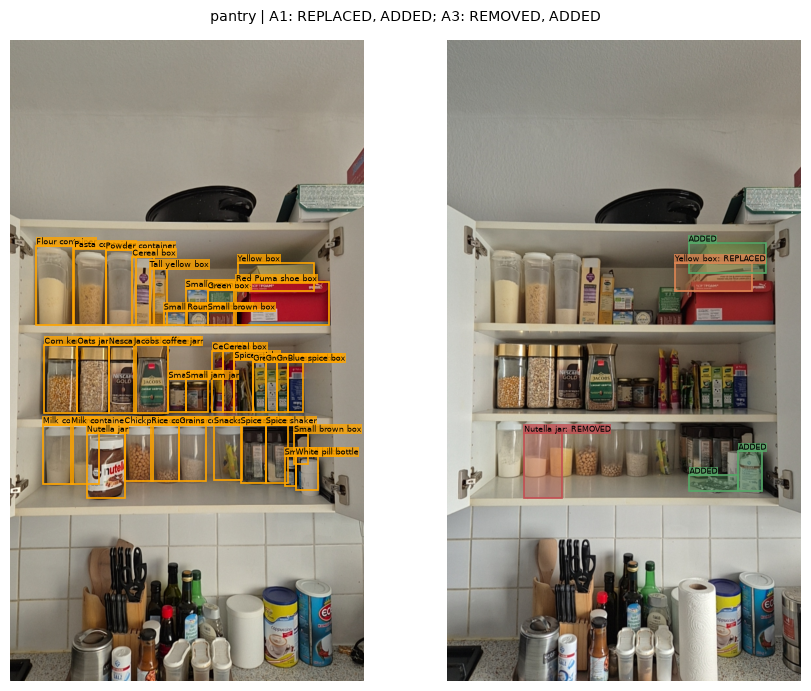

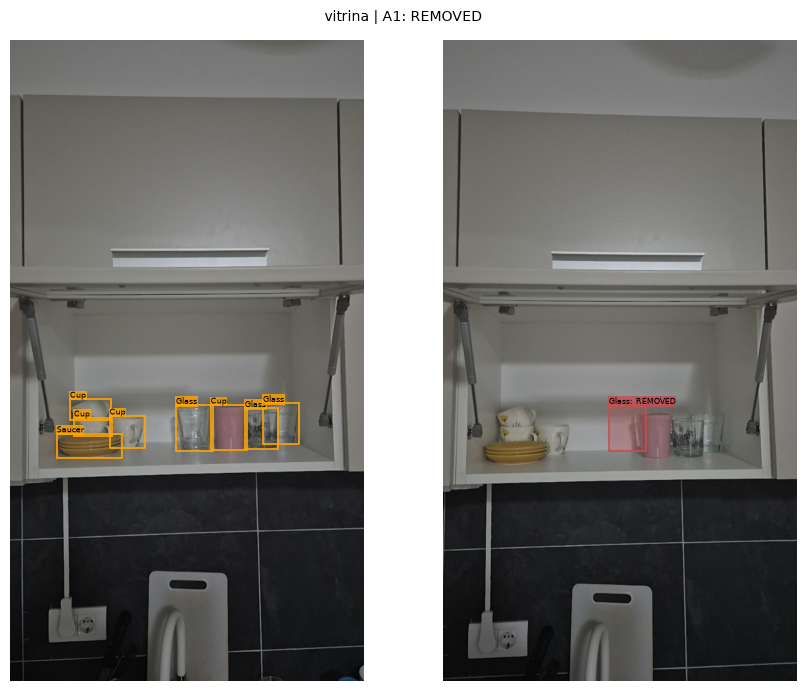

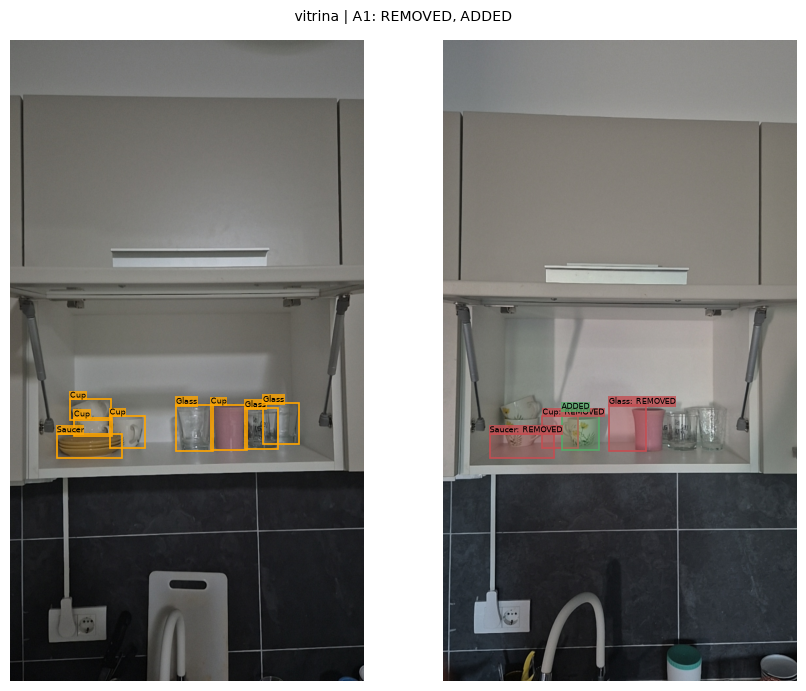

In [17]:
CHANGE_COLORS = {"REMOVED": "#C44E52", "ADDED": "#55A868", "REPLACED": "#DD8452"}
MARKED_ITEM_COLOR = "orange"


def draw_box(axis, image_size, box, color, label, filled=False):
    width, height = image_size
    x, y = box["x"] * width, box["y"] * height
    box_width, box_height = box["width"] * width, box["height"] * height
    if filled:
        axis.add_patch(patches.Rectangle((x, y), box_width, box_height, linewidth=0, facecolor=color, alpha=0.3))
    axis.add_patch(patches.Rectangle((x, y), box_width, box_height, linewidth=1.2, edgecolor=color, facecolor="none"))
    axis.text(x, y - 4, label, fontsize=6, color="black", bbox=dict(facecolor=color, alpha=0.8, pad=0.5, linewidth=0))


def show_item_marked_pair(golden):
    marked_items = {item["id"]: item for item in golden["marked_items"]}
    reference = Image.open(golden["reference_photo_path"]).convert("RGB")
    new_photo = Image.open(golden["photo_path"]).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(9, 7))
    axes[0].imshow(reference)
    axes[1].imshow(new_photo)
    for item in marked_items.values():
        draw_box(axes[0], reference.size, item["boundingBox"], MARKED_ITEM_COLOR, item["name"])
    for entry in golden["ground_truth"]:
        if "item_id" in entry:
            item = marked_items[entry["item_id"]]
            box, label = item["boundingBox"], f"{item['name']}: {entry['change']}"
        else:
            box, label = entry["box"], entry["change"]
        draw_box(axes[1], new_photo.size, box, CHANGE_COLORS[entry["change"]], label, filled=True)
    for axis in axes:
        axis.axis("off")
    fig.suptitle(f"{golden['storage_name']} | {describe_changes(golden)}", fontsize=10)
    plt.tight_layout()
    plt.show()


for golden in goldens.values():
    if has_item_markings(golden):
        show_item_marked_pair(golden)

## Running the Models

### Model Inputs

The models get the same input as the app's `ShelfDiffAnalyzer`: for every cell, a reference image and a new image, plus the list of known items in that cell. The inputs were prepared and are saved in `data/inputs/<golden>/`.

How they were prepared:
- **Reference cells:** the reference photo was cut into cells with the storage's guide lines. Every marked item was assigned to the cell that contains its center, and its box was converted to that cell: `[ymin, xmin, ymax, xmax]`, normalized to 0-1000. The known items are outlined with plain blue boxes on the reference cell.
- **New cells:** no homography was applied. The storage's guide lines were moved by hand onto the new photo (`grid_lines.json` in each golden folder), and the new photo was cut with these lines.
- **Images:** every cell image is scaled down to at most 768 px on the long side and saved as JPEG with quality 80, the same as the app.
- **Left out:** the minibar comparison taken against an older reference photo, because that reference has no item markings.

The prompt, response schema, and temperature (0) are copied from `ShelfDiffAnalyzerImpl.kt`. If the app's prompt changes, this copy has to be updated by hand.

Every response is saved to `data/responses/<model>/<golden>.json` with its latency and token counts. Saved responses are reused, so a model is called only for the comparisons that have no response yet. Calls are made only when `RUN_NEW_CALLS` is `True`. An earlier run is kept in `data/responses_run_1/`. To score it, point `RESPONSES_DIR` to that folder.

In [18]:
import os
import time

from dotenv import load_dotenv
from google import genai
from google.genai import types

RUN_NEW_CALLS = False
ONLY_GOLDENS = None

MODELS = [
    "gemini-3.5-flash-lite",
    "gemini-3.5-flash",
    "gemini-3.6-flash",
    "gemini-3.8-flash",
    "gemini-3.1-pro-preview",
]
TEMPERATURE = 0
REQUEST_TIMEOUT_S = 300
REQUEST_INTERVAL_S = 6.5
INPUTS_DIR = DATA_DIR / "inputs"
RESPONSES_DIR = DATA_DIR / "responses"
CHANGES = ["UNCHANGED", "REMOVED", "REPLACED", "ADDED", "PARTIALLY_CONSUMED", "FULLY_CONSUMED", "PARTIALLY_FILLED", "FULLY_FILLED", "UNKNOWN"]

PROMPT_INTRO = (
 "You are comparing shelf photos before and after a restock, cell by cell. For each cell " +
        "you are given a reference image (before) and a new image (after), plus a JSON list of " +
        "the known items already recorded in that cell — each also outlined with a plain blue " +
        "box (no label or number) in the reference image, at the position given by its box in " +
        "the JSON.\n" +
        "For every known item, look specifically at its own region in the new image — one item at " +
        "a time, not a single glance over the whole shelf — and report what happened to it. Do not " +
        "invent or assign any id — you identify which known item you mean purely by reporting a " +
        "box at (or close to) that item's known position; matching each report back to the correct " +
        "known item is done afterwards by comparing box positions, not by any id or label.\n" +
        "Do not default to UNCHANGED just because an item was in the known list. Removal is the " +
        "single most common change in a restock, so for every known item, actively check whether " +
        "it is still visibly present at that region before deciding: if the region now shows empty " +
        "shelf space, a bare shelf behind where the item used to be, or a different item, that is " +
        "not UNCHANGED — report REMOVED, REPLACED, or the appropriate fill-level change instead. " +
        "Only report UNCHANGED when you can actually see that same item still occupying that " +
        "region in the new image.\n" +
        "If you see an item in the new image that isn't one of the known items, report it too, as " +
        "a newly seen item.\n" +
        "For each item, report:\n" +
        "- box: tight bounding box of the item's current extent in the new image, or its last " +
        "known extent if it's now gone. Same [ymin, xmin, ymax, xmax] normalized 0-1000 " +
        "convention as the known items' boxes, relative to this cell's image. Always required.\n" +
        "- change: one of UNCHANGED, REMOVED (item physically gone), REPLACED (a different item " +
        "now occupies the same spot), ADDED (newly seen item, not one of the known items), " +
        "PARTIALLY_CONSUMED (transparent container, fill level clearly and significantly dropped " +
        "but not empty), " +
        "FULLY_CONSUMED (transparent container, now empty, container still present), " +
        "PARTIALLY_FILLED (transparent container, fill level clearly and significantly increased " +
        "but not full), " +
        "FULLY_FILLED (transparent container, topped up to full), or UNKNOWN (can't tell, e.g. " +
        "occlusion or a bad angle — use this rather than guessing).\n" +
        "- description: a brief note on what you saw and why you picked that change value.\n" +
        "The four fill-level values only apply to transparent containers — never use them for an " +
        "item that isn't one. Only use PARTIALLY_CONSUMED or PARTIALLY_FILLED when the fill level " +
        "difference is large enough to be obvious at a glance — small or ambiguous variations that " +
        "could just be lighting/angle differences should be reported as UNCHANGED instead.\n" +
        "For an ADDED or REPLACED item, also report: name and isTransparentContainer. name is " +
        "the item's plain-language name, 2-4 words (e.g. \"Sweetener container\"), picking a " +
        "single name even if more than one description would fit — do not combine alternatives, " +
        "and do not include ids, quotes, or punctuation such as braces or brackets in it.\n" +
        "Respond with one entry per cell, each containing the full list of item results for " +
        "that cell."
)

RESPONSE_SCHEMA = {
    "type": "array",
    "items": {
        "type": "object",
        "properties": {
            "cellId": {"type": "string"},
            "items": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "change": {"type": "string", "enum": CHANGES},
                        "description": {"type": "string"},
                        "box": {"type": "array", "items": {"type": "integer"}},
                        "name": {"type": "string", "nullable": True},
                        "isTransparentContainer": {"type": "boolean", "nullable": True},
                    },
                    "required": ["change", "description", "box"],
                },
            },
        },
        "required": ["cellId", "items"],
    },
}

load_dotenv(NOTEBOOK_DIR.parent / ".env")
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
if RUN_NEW_CALLS and not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY is missing in experiments/.env")
client = genai.Client(api_key=GEMINI_API_KEY) if RUN_NEW_CALLS else None


def image_part(path):
    return types.Part.from_bytes(data=path.read_bytes(), mime_type="image/jpeg")


def known_items_json(known_items):
    return json.dumps(
        [{"name": item["name"], "isTransparentContainer": item["isTransparentContainer"], "box": item["box"]} for item in known_items],
        separators=(",", ":"),
        ensure_ascii=False,
    )


def build_request(golden_inputs_dir):
    input_data = json.loads((golden_inputs_dir / "input.json").read_text(encoding="utf-8"))
    parts = [PROMPT_INTRO]
    for cell in input_data["cells"]:
        parts.append(f"Cell {cell['cellId']} - reference:")
        if cell["knownItems"]:
            parts.append(f"Known items in this cell: {known_items_json(cell['knownItems'])}")
        parts.append(image_part(golden_inputs_dir / cell["referenceImage"]))
        parts.append(f"Cell {cell['cellId']} - new:")
        parts.append(image_part(golden_inputs_dir / cell["newImage"]))
    return parts


def call_model(model_name, parts):
    config = types.GenerateContentConfig(
        temperature=TEMPERATURE,
        response_mime_type="application/json",
        response_schema=RESPONSE_SCHEMA,
        http_options=types.HttpOptions(timeout=REQUEST_TIMEOUT_S * 1000),
    )
    started = time.perf_counter()
    response = client.models.generate_content(model=model_name, contents=parts, config=config)
    latency_s = time.perf_counter() - started
    return {
        "latency_s": round(latency_s, 2),
        "prompt_tokens": response.usage_metadata.prompt_token_count,
        "output_tokens": response.usage_metadata.candidates_token_count,
        "thinking_tokens": response.usage_metadata.thoughts_token_count,
        "text": response.text,
    }

In [19]:
def response_path(model_name, golden_name):
    return RESPONSES_DIR / model_name / f"{golden_name}.json"


golden_inputs_dirs = sorted(
    path for path in INPUTS_DIR.iterdir()
    if path.is_dir() and (ONLY_GOLDENS is None or path.name in ONLY_GOLDENS)
)
missing = [
    (model_name, golden_dir)
    for model_name in MODELS
    for golden_dir in golden_inputs_dirs
    if not response_path(model_name, golden_dir.name).exists()
]
print(f"comparisons: {len(golden_inputs_dirs)}, models: {len(MODELS)}")
print(f"saved responses: {len(MODELS) * len(golden_inputs_dirs) - len(missing)}, missing: {len(missing)}")

if RUN_NEW_CALLS:
    for index, (model_name, golden_dir) in enumerate(missing):
        if index > 0:
            time.sleep(REQUEST_INTERVAL_S)
        try:
            record = {"model": model_name, "golden": golden_dir.name, **call_model(model_name, build_request(golden_dir))}
        except Exception as error:
            print(f"{model_name} | {golden_dir.name}: {type(error).__name__}: {error}")
            continue
        path = response_path(model_name, golden_dir.name)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(record, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
        print(f"{model_name} | {golden_dir.name}: {record['latency_s']} s")

comparisons: 9, models: 5
saved responses: 45, missing: 0


## Results

### How the Responses Are Scored

Each answer is compared with the ground truth at two levels.

- **Item level (7 comparisons):** for every known item, did the model report the right change (for example `REMOVED`)? An item the model does not mention counts as `UNCHANGED`. Only comparisons where the ground truth names the changed items, or has no change at all, are used here.
- **Cell level (all 9 comparisons):** did the model notice that a cell changed? *Detection* only checks changed or unchanged. *Exact* also needs the same types of change as the ground truth.
- **Matching:** the model reports a box for each item. We match it to the known item whose box overlaps it most, the same way the app does. Cell names written as `Cell A1` are read as `A1`, and the table shows how often a model did this.
- **Added items:** an added item counts as found if the model's box overlaps the box of the added item in the ground truth. There is only one such box, so this is a weak test.
- **Speed:** an answer that takes more than 60 seconds is too slow for the app.
- **Cost:** calculated from the tokens used and the prices in the model table above. Thinking tokens count as output. The Flash prices are promotional and roughly double after 31 Dec 2026.
- **Scores:** accuracy is the share of correct results. Precision is the share of reported changes that were real. Recall is the share of real changes that were found. F1 combines the two. Almost all items are `UNCHANGED`, so every model gets a high item-level score. The confusion matrices below show the changed items.

In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

APP_TIMEOUT_S = 60
PRICES_PER_MILLION_TOKENS = {
    "gemini-3.5-flash-lite": (0.30, 2.50),
    "gemini-3.5-flash": (1.50, 9.00),
    "gemini-3.6-flash": (0.75, 3.75),
    "gemini-3.8-flash": (0.75, 3.75),
    "gemini-3.1-pro-preview": (2.00, 12.00),
}
NOT_DETECTED = {"UNCHANGED", "UNKNOWN"}
FILL_LEVEL_CHANGES = {"PARTIALLY_CONSUMED", "FULLY_CONSUMED", "PARTIALLY_FILLED", "FULLY_FILLED"}


def box_iou(first, second):
    top, left = max(first[0], second[0]), max(first[1], second[1])
    bottom, right = min(first[2], second[2]), min(first[3], second[3])
    intersection = max(bottom - top, 0) * max(right - left, 0)
    union = (first[2] - first[0]) * (first[3] - first[1]) + (second[2] - second[0]) * (second[3] - second[1]) - intersection
    return intersection / union if union > 0 else 0.0


def center_distance(first, second):
    return ((first[0] + first[2] - second[0] - second[2]) ** 2 + (first[1] + first[3] - second[1] - second[3]) ** 2) ** 0.5 / 2


def match_by_overlap(predicted_boxes, truth_boxes):
    candidates = sorted(
        ((box_iou(truth, predicted), predicted_index, truth_index)
         for predicted_index, predicted in enumerate(predicted_boxes)
         for truth_index, truth in enumerate(truth_boxes)),
        reverse=True,
    )
    matches = {}
    for overlap, predicted_index, truth_index in candidates:
        if overlap <= 0:
            break
        if predicted_index not in matches and truth_index not in matches.values():
            matches[predicted_index] = truth_index
    return matches


def match_to_known_items(reported_items, known_items):
    matches = match_by_overlap([item["box"] for item in reported_items], [known["box"] for known in known_items])
    for reported_index, reported in enumerate(reported_items):
        free = [index for index in range(len(known_items)) if index not in matches.values()]
        if reported_index in matches or not free:
            continue
        matches[reported_index] = min(free, key=lambda index: center_distance(known_items[index]["box"], reported["box"]))
    return {known_index: reported_items[reported_index] for reported_index, known_index in matches.items()}


def resolved_change(reported, known):
    if reported["change"] in FILL_LEVEL_CHANGES and not known["isTransparentContainer"]:
        return "UNKNOWN"
    return reported["change"]


def new_cell_bounds(golden_name, cell_id):
    lines = json.loads((GOLDENS_DIR / golden_name / "grid_lines.json").read_text(encoding="utf-8"))
    rows = sorted(line["position"] for line in lines if line["isHorizontal"])
    columns = sorted(line["position"] for line in lines if not line["isHorizontal"])
    row, column = int(cell_id[1:]) - 1, ord(cell_id[0]) - ord("A")
    return columns[column], rows[row], columns[column + 1], rows[row + 1]


def photo_box(cell_box, bounds):
    left, top, right, bottom = bounds
    width, height = right - left, bottom - top
    return [top + cell_box[0] / 1000 * height, left + cell_box[1] / 1000 * width, top + cell_box[2] / 1000 * height, left + cell_box[3] / 1000 * width]


def truth_photo_box(box):
    return [box["y"], box["x"], box["y"] + box["height"], box["x"] + box["width"]]


def score_response(golden_name, record):
    inputs = json.loads((INPUTS_DIR / golden_name / "input.json").read_text(encoding="utf-8"))
    reported_by_cell = {}
    for cell in json.loads(record["text"]):
        reported_by_cell[cell["cellId"].removeprefix("Cell ").strip()] = cell["items"]
    ground_truth = goldens[golden_name]["ground_truth"]
    item_level = not ground_truth or has_item_markings(goldens[golden_name])
    true_changes = {entry["item_id"]: entry["change"] for entry in ground_truth if "item_id" in entry}
    item_rows, cell_rows, added_boxes = [], [], []
    for cell in inputs["cells"]:
        cell_id = cell["cellId"]
        reported = reported_by_cell.get(cell_id, [])
        matches = match_to_known_items([item for item in reported if item["change"] != "ADDED"], cell["knownItems"])
        resolved = {index: resolved_change(reported_item, cell["knownItems"][index]) for index, reported_item in matches.items()}
        added = [item for item in reported if item["change"] == "ADDED"]
        predicted_set = {change for change in resolved.values() if change not in NOT_DETECTED} | ({"ADDED"} if added else set())
        true_set = {entry["change"] for entry in ground_truth if entry["cell"] == cell_id}
        cell_rows.append({"true_changed": bool(true_set), "predicted_changed": bool(predicted_set), "exact": predicted_set == true_set})
        if item_level:
            for index, known in enumerate(cell["knownItems"]):
                item_rows.append({"true": true_changes.get(known["id"], "UNCHANGED"), "predicted": resolved.get(index, "UNCHANGED")})
            bounds = new_cell_bounds(golden_name, cell_id)
            added_boxes += [photo_box(item["box"], bounds) for item in added]
    added_truth = [truth_photo_box(entry["box"]) for entry in ground_truth if entry["change"] == "ADDED" and "box" in entry] if item_level else []
    found = len(match_by_overlap(added_boxes, added_truth))
    added_row = {"found": found, "false_alarms": len(added_boxes) - found, "missed": len(added_truth) - found}
    bad_cell_id = any(cell["cellId"] != cell["cellId"].removeprefix("Cell ").strip() for cell in json.loads(record["text"]))
    return item_rows, cell_rows, added_row, bad_cell_id


def load_record(model_name, golden_name):
    path = response_path(model_name, golden_name)
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


def f1_score_of(true_positives, false_positives, false_negatives):
    denominator = 2 * true_positives + false_positives + false_negatives
    return 2 * true_positives / denominator if denominator else 0.0


def response_cost(model_name, record):
    prices = PRICES_PER_MILLION_TOKENS[model_name]
    if prices is None:
        return None
    output_tokens = record["output_tokens"] + (record["thinking_tokens"] or 0)
    return (record["prompt_tokens"] * prices[0] + output_tokens * prices[1]) / 1_000_000

In [21]:
speed_rows, metric_rows, check_rows = [], [], []
item_rows_by_model, cell_rows_by_model = {}, {}
for model_name in MODELS:
    records = {golden_dir.name: load_record(model_name, golden_dir.name) for golden_dir in sorted(INPUTS_DIR.iterdir()) if golden_dir.is_dir()}
    records = {name: record for name, record in records.items() if record is not None}
    item_rows, cell_rows, added_rows, bad_cell_ids = [], [], [], 0
    for golden_name, record in records.items():
        golden_items, golden_cells, golden_added, bad_cell_id = score_response(golden_name, record)
        item_rows += golden_items
        cell_rows += golden_cells
        added_rows.append(golden_added)
        bad_cell_ids += bad_cell_id
    item_rows_by_model[model_name] = item_rows
    cell_rows_by_model[model_name] = cell_rows
    costs = [response_cost(model_name, record) for record in records.values()]
    speed_rows.append({
        "model": model_name,
        "responses": len(records),
        "avg latency (s)": round(sum(r["latency_s"] for r in records.values()) / len(records), 1),
        "over 60 s": sum(r["latency_s"] > APP_TIMEOUT_S for r in records.values()),
        "prompt tokens": sum(r["prompt_tokens"] for r in records.values()),
        "output tokens": sum(r["output_tokens"] for r in records.values()),
        "thinking tokens": sum(r["thinking_tokens"] or 0 for r in records.values()),
        "avg cost per scan ($)": round(sum(costs) / len(costs), 4) if None not in costs else "unknown price",
    })
    item_true = [row["true"] for row in item_rows]
    item_predicted = [row["predicted"] for row in item_rows]
    item_precision, item_recall, item_f1, _ = precision_recall_fscore_support(item_true, item_predicted, labels=CHANGES, average="weighted", zero_division=0)
    cell_true = [int(row["true_changed"]) for row in cell_rows]
    cell_predicted = [int(row["predicted_changed"]) for row in cell_rows]
    cell_precision, cell_recall, cell_f1, _ = precision_recall_fscore_support(cell_true, cell_predicted, average="binary", zero_division=0)
    metric_rows.append([
        accuracy_score(item_true, item_predicted), item_precision, item_recall, item_f1,
        accuracy_score(cell_true, cell_predicted), cell_precision, cell_recall, cell_f1,
    ])
    changed_items = [row for row in item_rows if row["true"] != "UNCHANGED"]
    check_rows.append({
        "model": model_name,
        "cell exact": f"{sum(row['exact'] for row in cell_rows)}/{len(cell_rows)}",
        "changed items found": f"{sum(row['predicted'] == row['true'] for row in changed_items)}/{len(changed_items)}",
        "ADDED found/false/missed": "/".join(str(sum(row[key] for row in added_rows)) for key in ("found", "false_alarms", "missed")),
        "bad cell id": bad_cell_ids,
    })

metric_columns = pd.MultiIndex.from_product([["item level", "cell level"], ["accuracy", "precision", "recall", "F1"]])
display(pd.DataFrame(speed_rows).set_index("model"))
display(pd.DataFrame(metric_rows, index=MODELS, columns=metric_columns).round(2))
display(pd.DataFrame(check_rows).set_index("model"))

,responses,avg latency (s),over 60 s,prompt tokens,output tokens,thinking tokens,avg cost per scan ($)
model,,,,,,,
gemini-3.5-flash-lite,9,4.5,0,59365,12914,0,0.0056
gemini-3.5-flash,9,19.2,0,59365,13728,35075,0.0587
gemini-3.6-flash,9,24.7,0,59365,12992,33050,0.0241
gemini-3.8-flash,9,21.0,0,59365,12110,52408,0.0318
gemini-3.1-pro-preview,9,45.1,1,59365,14283,49922,0.0988


item level                        cell level            \
                         accuracy precision recall    F1   accuracy precision   
gemini-3.5-flash-lite        0.95      0.95   0.95  0.95       0.90      1.00   
gemini-3.5-flash             0.98      0.97   0.98  0.98       1.00      1.00   
gemini-3.6-flash             0.95      0.97   0.95  0.96       0.95      0.90   
gemini-3.8-flash             0.96      0.96   0.96  0.96       0.90      0.89   
gemini-3.1-pro-preview       0.96      0.97   0.96  0.96       0.76      0.67   

                                     
                       recall    F1  
gemini-3.5-flash-lite    0.78  0.88  
gemini-3.5-flash         1.00  1.00  
gemini-3.6-flash         1.00  0.95  
gemini-3.8-flash         0.89  0.89  
gemini-3.1-pro-preview   0.89  0.76

,cell exact,changed items found,ADDED found/false/missed,bad cell id
model,,,,
gemini-3.5-flash-lite,17/21,4/8,3/1/2,7
gemini-3.5-flash,17/21,6/8,4/6/1,0
gemini-3.6-flash,15/21,6/8,2/4/3,0
gemini-3.8-flash,14/21,5/8,3/6/2,0
gemini-3.1-pro-preview,11/21,4/8,3/4/2,0


### Confusion Matrices

Rows are the ground truth, columns are what the model reported. The first row of matrices is at item level, over the change types that occur in the ground truth or in any model's answer. The second row is at cell level.

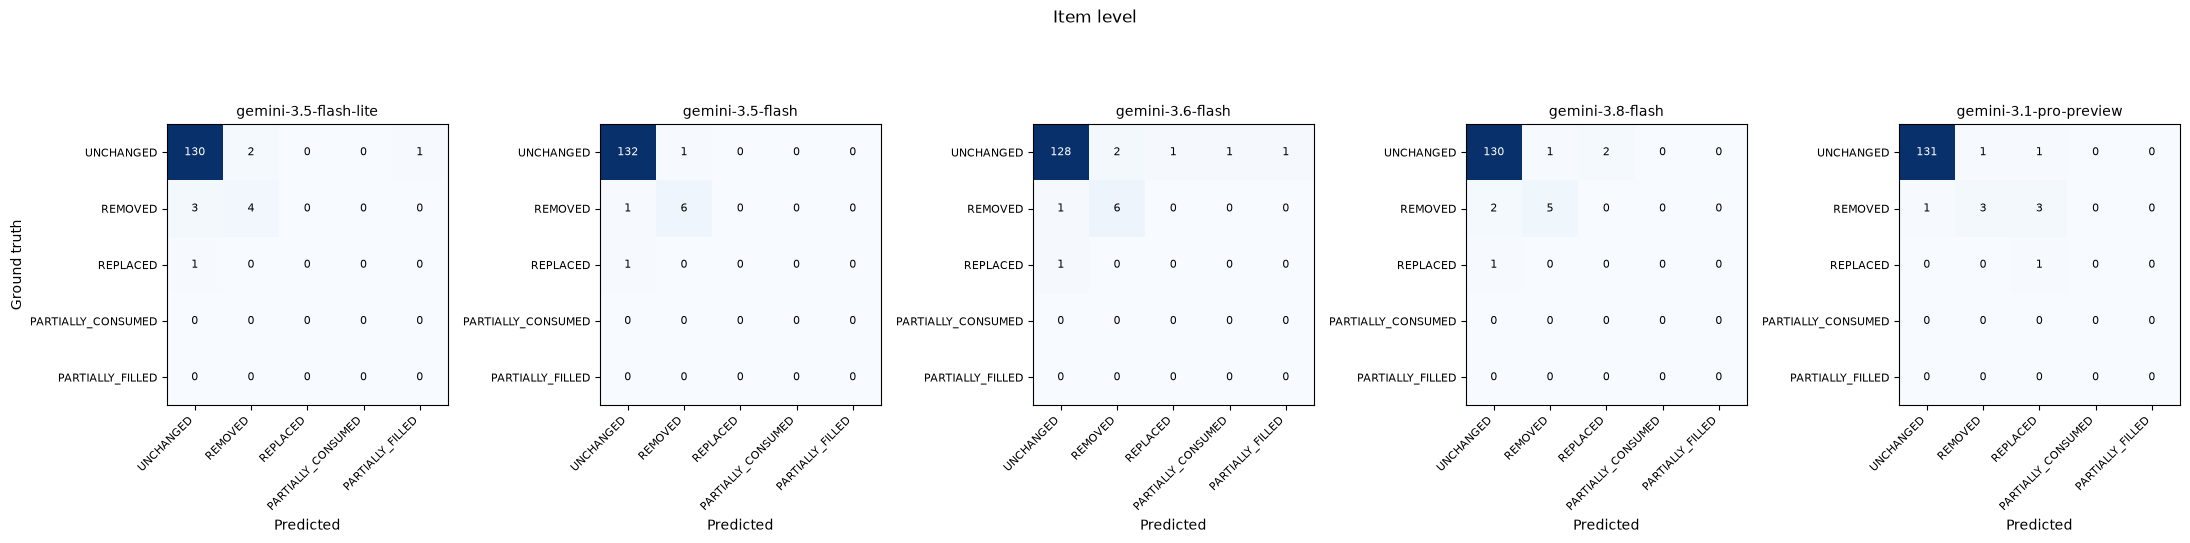

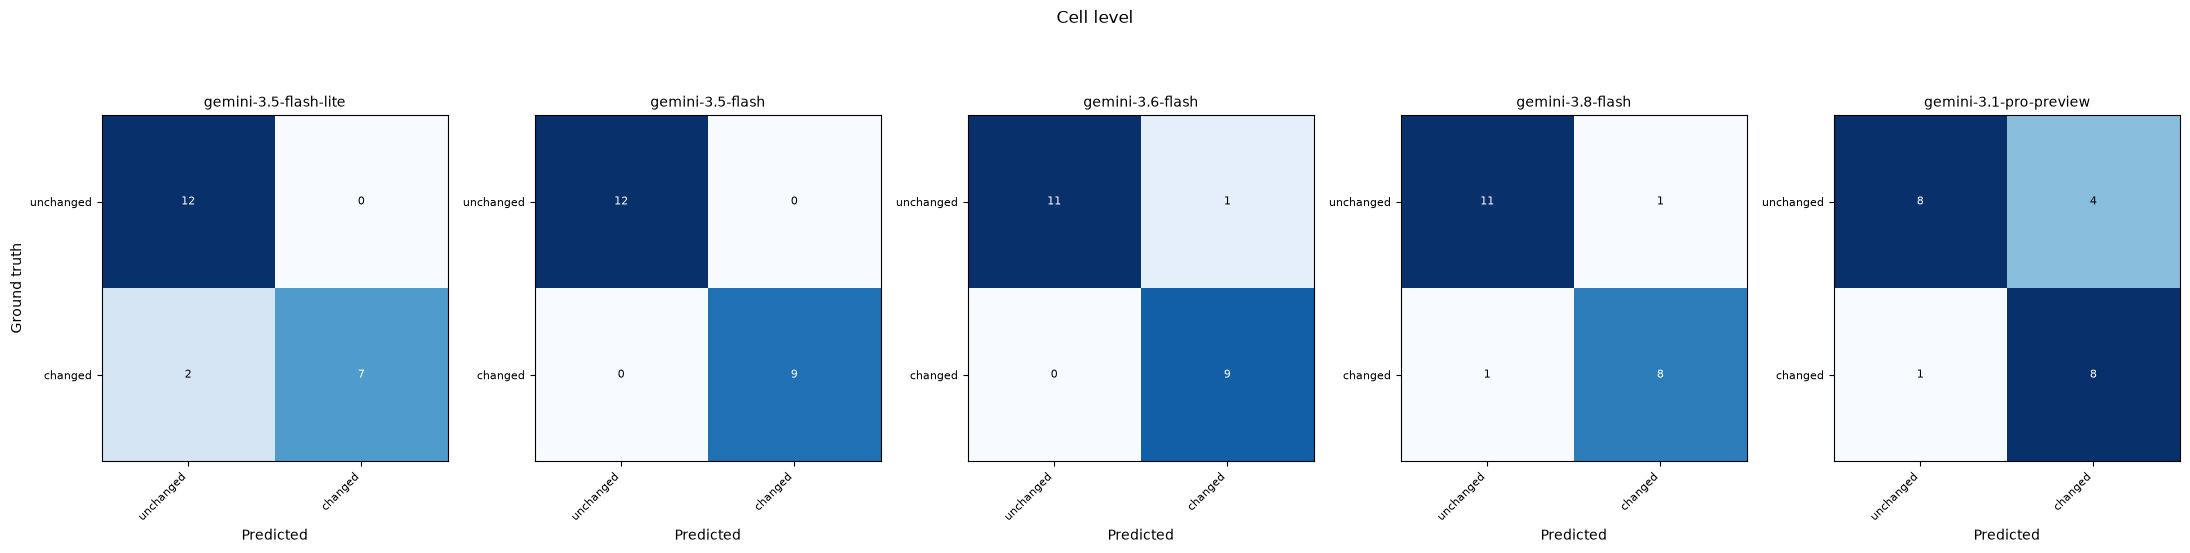

In [22]:
def draw_confusion_matrices(true_by_model, predicted_by_model, labels, title):
    fig, axes = plt.subplots(1, len(MODELS), figsize=(4.4 * len(MODELS), 5.6))
    for axis, model_name in zip(axes, MODELS):
        matrix = confusion_matrix(true_by_model[model_name], predicted_by_model[model_name], labels=labels)
        axis.imshow(matrix, cmap="Blues")
        axis.set_xticks(range(len(labels)))
        axis.set_yticks(range(len(labels)))
        axis.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        axis.set_yticklabels(labels, fontsize=8)
        axis.set_xlabel("Predicted")
        axis.set_title(model_name, fontsize=10)
        for row in range(len(labels)):
            for column in range(len(labels)):
                axis.text(column, row, matrix[row, column], ha="center", va="center", fontsize=8, color="white" if matrix[row, column] > matrix.max() / 2 else "black")
    axes[0].set_ylabel("Ground truth")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


item_labels = [
    change for change in CHANGES
    if any(change in (row["true"], row["predicted"]) for rows in item_rows_by_model.values() for row in rows)
]
draw_confusion_matrices(
    {name: [row["true"] for row in rows] for name, rows in item_rows_by_model.items()},
    {name: [row["predicted"] for row in rows] for name, rows in item_rows_by_model.items()},
    item_labels,
    "Item level",
)
draw_confusion_matrices(
    {name: ["changed" if row["true_changed"] else "unchanged" for row in rows] for name, rows in cell_rows_by_model.items()},
    {name: ["changed" if row["predicted_changed"] else "unchanged" for row in rows] for name, rows in cell_rows_by_model.items()},
    ["unchanged", "changed"],
    "Cell level",
)

## Discussion

All five models got the same photos and the same prompt. The results come from 9 comparisons, 21 cells and 8 changed items, so small differences do not mean much.

- **Item-level scores say little.** Almost all items are unchanged, so every model has an accuracy of 0.95 to 0.98. It is more useful to look at the changed items: the best models found 6 of 8, the others 4 or 5.
- **`gemini-3.5-flash` was the most accurate.** It got every changed cell right (cell-level F1 1.00). `gemini-3.6-flash` was close (F1 0.95, also 6 of 8 changed items).
- **`gemini-3.5-flash-lite` is very fast and cheap** (4.5 s and 0.006 per scan). But it found only 4 of 8 changed items and missed more changed cells (recall 0.78).
- **`gemini-3.1-pro-preview` was not better.** It was the slowest (45 s on average, and one answer took 82 s, over the 60 s limit). It was the most expensive (0.099 per scan) and had the lowest cell-level F1 (0.76), because it reported changes in cells that had none.
- **Added items are hard for every model.** There were 5 added items. Each model found 2 to 4 of them, and each reported 1 to 6 added items that were not there.
- **Limits:** the photos were not aligned, each model ran once, and the data is small. The Flash prices are promotional until 31 Dec 2026.

## Conclusion

- Online Gemini models can detect changes on a shelf, but none is perfect. The best one found 6 of 8 changed items and still made false reports of added items.
- A bigger and more expensive model was not better. Pro was the worst at cell level, so it is not worth the price.
- The Flash tier fits best. `gemini-3.5-flash` was the most accurate. `gemini-3.6-flash`, which the app uses now, was close and is cheaper until the promotion ends. After that the two cost about the same. With this little data we cannot say which one is really better, so **we suggest keeping `gemini-3.6-flash`**.
- `gemini-3.5-flash-lite` is an option if cost and speed matter more than catching every change, because it misses more of them.